# Review 1 — Regression 



**Algorithms**
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor (KNN)

The notebook uses the same cleaned, stratified 80:20 train/test split for all models.


## 0. Imports and configuration

In [62]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_PATH = r"airfoil_with_missing.csv"
TARGET = "Scaled_Sound_Pressure_Level_dB"

# Results 
results = []
predictions_store = {}
models_store = {}
params_store = {}

print("Configuration loaded.")
print("Target:", TARGET)
print("Test size:", TEST_SIZE)


Configuration loaded.
Target: Scaled_Sound_Pressure_Level_dB
Test size: 0.2


## 1. Dataset loading

In [63]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1503, 6)


,Frequency_Hz,Angle_of_Attack_deg,Chord_Length_m,Free_Stream_Velocity_mps,Suction_Side_Displacement_Thickness_m,Scaled_Sound_Pressure_Level_dB
0,800.0,0.0,0.3048,71.3,0.002663,126.201
1,1000.0,0.0,0.3048,71.3,0.002663,125.201
2,1250.0,0.0,0.3048,71.3,0.002663,125.951
3,1600.0,0.0,0.3048,71.3,0.002663,127.591
4,2000.0,0.0,0.3048,71.3,0.002663,127.461


## 1A. Dataset audit — shape, dtypes, missing values, duplicates and target

In [64]:
print("Shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution summary:")
display(df[TARGET].describe().to_frame("value"))

print("\nTarget missing values:", df[TARGET].isna().sum())


Shape: (1503, 6)

Data types:


,dtype
Frequency_Hz,float64
Angle_of_Attack_deg,float64
Chord_Length_m,float64
Free_Stream_Velocity_mps,float64
Suction_Side_Displacement_Thickness_m,float64
Scaled_Sound_Pressure_Level_dB,float64



Missing values:


,missing_count
Frequency_Hz,75
Angle_of_Attack_deg,75
Chord_Length_m,75
Free_Stream_Velocity_mps,75
Suction_Side_Displacement_Thickness_m,75
Scaled_Sound_Pressure_Level_dB,0



Duplicate rows: 0

Target distribution summary:


,value
count,1503.000000
mean,124.835943
std,6.898657
min,103.380000
25%,120.191000
50%,125.721000
75%,129.995500
max,140.987000



Target missing values: 0


### Audit observation

The audit above reports the dataset shape, feature data types, missing-value counts, duplicate count, and target summary. These checks establish the starting data quality before preprocessing.


## 2. Exploratory Data Analysis — feature distributions

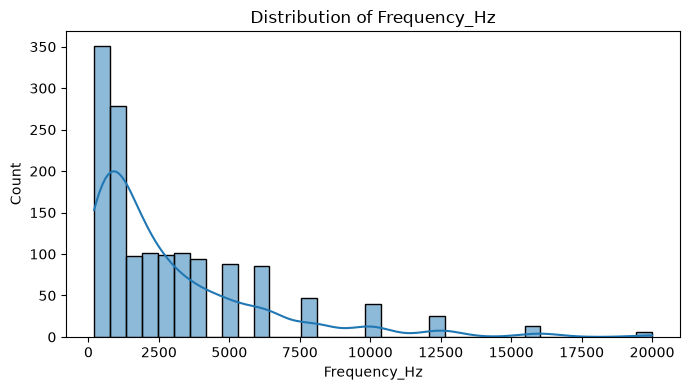

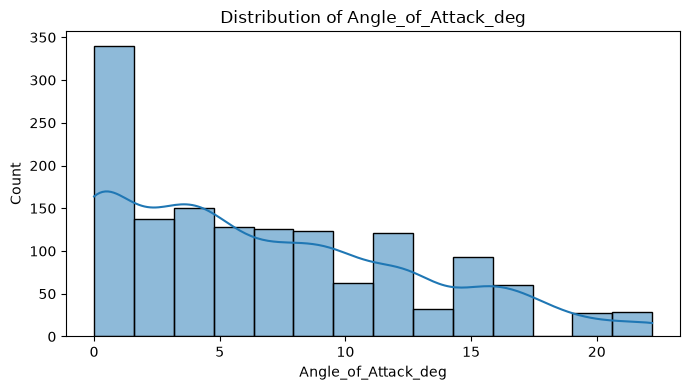

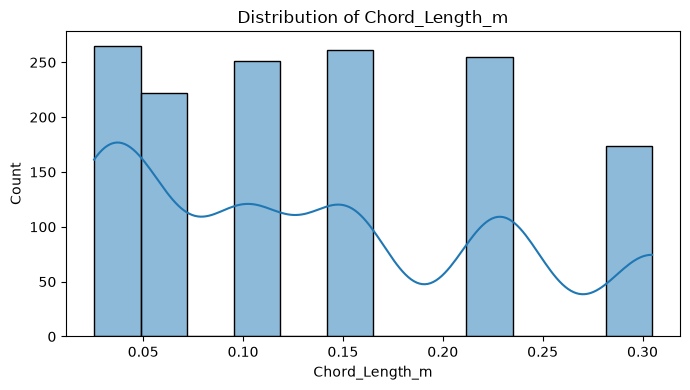

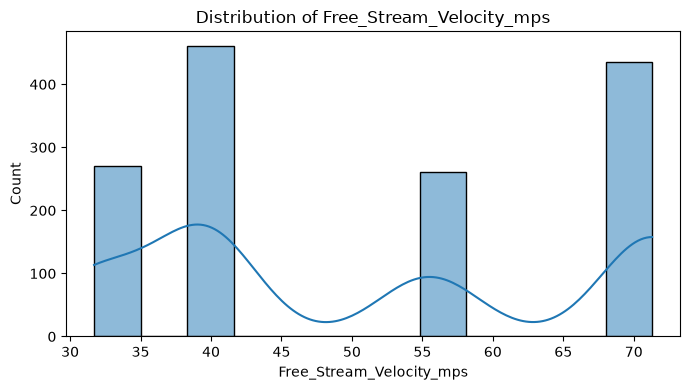

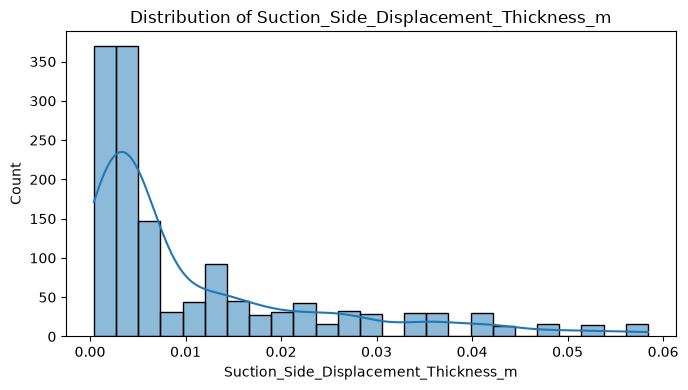

In [65]:
feature_cols = [c for c in df.columns if c != TARGET]

for col in feature_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### Distribution observations

- The feature distributions should be inspected for skewness, concentration and unusual values.
- In the supplied dataset, the Frequency and Suction-Side Displacement Thickness distributions show visible skew/concentration.
- Angle of Attack, chord length and free-stream velocity are comparatively well distributed.



## 2A. Target distribution

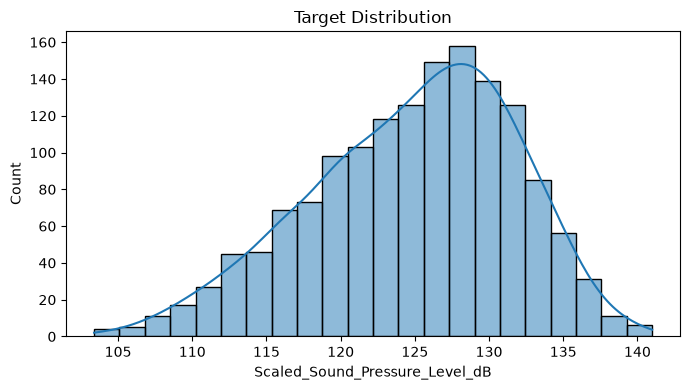

In [66]:
plt.figure(figsize=(7, 4))
sns.histplot(df[TARGET], kde=True)
plt.title("Target Distribution")
plt.xlabel(TARGET)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Target observation

The target distribution is approximately bell-shaped in the supplied dataset, with no obvious severe skewness from the overall histogram.


## 2B. Correlation heatmap

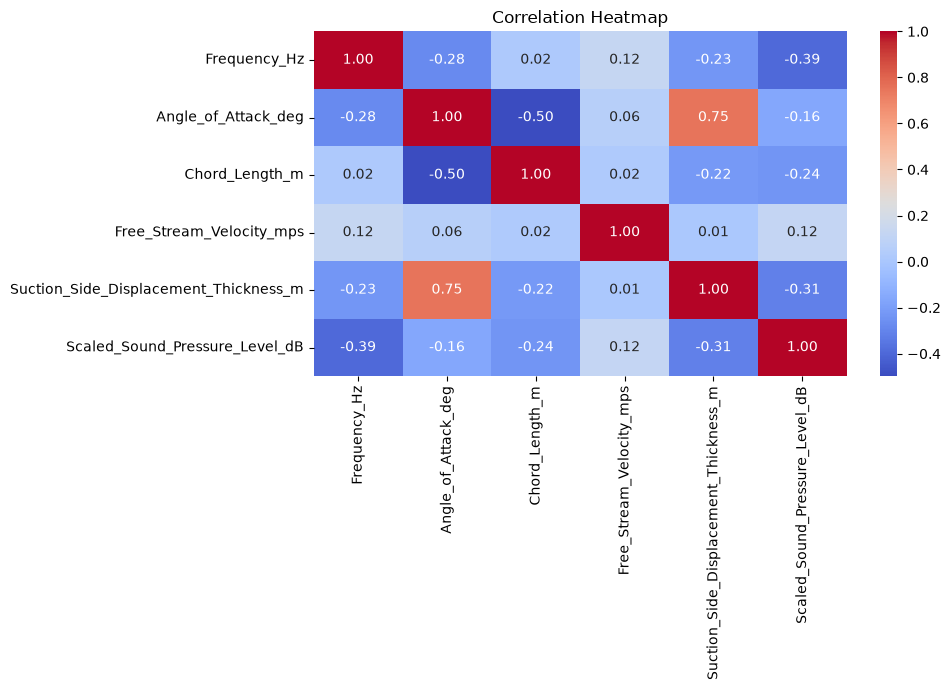

In [67]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Correlation observation

The heatmap shows the linear relationship between the numerical variables and the target. In the supplied dataset, Frequency has the strongest negative correlation with the target, followed by Suction-Side Displacement Thickness. Chord Length and Angle of Attack have weaker negative relationships, while Free-Stream Velocity has a weak positive relationship.


## 2C. Feature–target scatter plots

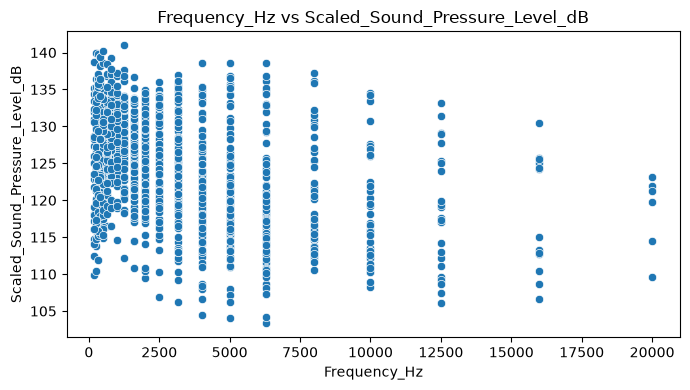

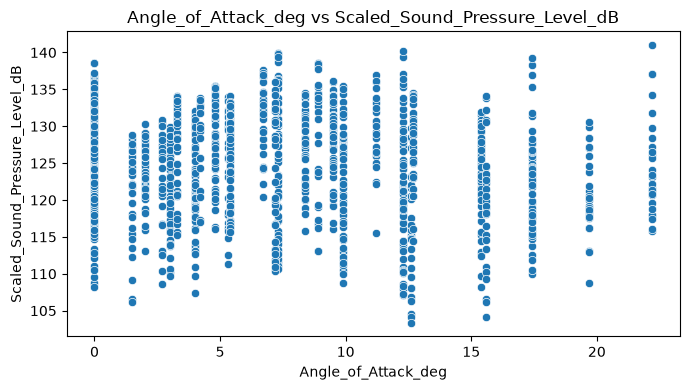

In [68]:

scatter_features = [c for c in ["Frequency_Hz", "Angle_of_Attack_deg"] if c in feature_cols]

# first two if the above columns not there
if len(scatter_features) < 2:
    scatter_features = feature_cols[:2]

for col in scatter_features:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df, x=col, y=TARGET)
    plt.title(f"{col} vs {TARGET}")
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()


### Scatter-plot observations

- Frequency versus target shows a generally downward pattern, consistent with its negative correlation, although the observations are scattered.
- Angle of Attack versus target is more scattered and does not show a strong simple linear pattern.



## 3. Data cleaning — duplicates, target validity and missing values

In [69]:
# Remove exact duplicate rows.
duplicate_count = int(df.duplicated().sum())
df_clean = df.drop_duplicates().copy()

# A missing target removed
missing_target_count = int(df_clean[TARGET].isna().sum())
df_clean = df_clean.dropna(subset=[TARGET]).copy()

print("Duplicate rows removed:", duplicate_count)
print("Rows with missing target removed:", missing_target_count)
print("Shape after basic cleaning:", df_clean.shape)

print("\nRemaining missing values by column:")
display(df_clean.isna().sum().to_frame("missing_count"))


Duplicate rows removed: 0
Rows with missing target removed: 0
Shape after basic cleaning: (1503, 6)

Remaining missing values by column:


,missing_count
Frequency_Hz,75
Angle_of_Attack_deg,75
Chord_Length_m,75
Free_Stream_Velocity_mps,75
Suction_Side_Displacement_Thickness_m,75
Scaled_Sound_Pressure_Level_dB,0


### Cleaning observation

Exact duplicate rows are removed. Rows with a missing target are removed because there is no observed target value with which to train or evaluate a supervised regression model. Feature missing values are handled later using training-set-only imputation to prevent data leakage.


## 3A. Feature engineering

In [70]:
X = df_clean.drop(columns=[TARGET]).copy()
y = df_clean[TARGET].copy()

# Required engineered feature: interaction between Angle of Attack and Free-Stream Velocity.
if {"Angle_of_Attack_deg", "Free_Stream_Velocity_mps"}.issubset(X.columns):
    X["Velocity_AOA_Interaction"] = (
        X["Angle_of_Attack_deg"] * X["Free_Stream_Velocity_mps"]
    )
    engineered_feature = "Velocity_AOA_Interaction"
else:
 
    engineered_feature = X.columns[0]
    X["Engineered_Squared_Feature"] = X[engineered_feature] ** 2
    engineered_feature = "Engineered_Squared_Feature"

print("Engineered feature:", engineered_feature)
print("Total features after engineering:", X.shape[1])
print("Features:", list(X.columns))


Engineered feature: Velocity_AOA_Interaction
Total features after engineering: 6
Features: ['Frequency_Hz', 'Angle_of_Attack_deg', 'Chord_Length_m', 'Free_Stream_Velocity_mps', 'Suction_Side_Displacement_Thickness_m', 'Velocity_AOA_Interaction']


### Feature-engineering justification

`Velocity_AOA_Interaction` multiplies Angle of Attack by Free-Stream Velocity. This can represent a combined aerodynamic effect that may not be captured by either variable independently, giving nonlinear/tree-based models and interaction-aware models an additional signal.


## 3B. Train/test split - 80:20 split

In [71]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
   
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Train percentage:", round(len(X_train) / len(X) * 100, 2), "%")
print("Test percentage:", round(len(X_test) / len(X) * 100, 2), "%")


Training samples: 1202
Test samples: 301
Train percentage: 79.97 %
Test percentage: 20.03 %


### Split observation

All 10 algorithms use exactly the same 80:20 train/test split. Because this is a regression target.


## 3C. Missing-value imputation

In [72]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


if categorical_features:
    print("Categorical columns detected. They require encoding before model fitting.")
else:
    print("No categorical columns detected; categorical encoding is not required for this dataset.")

imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index
)

print("\nMissing values after imputation:")
print("Train:", int(X_train_imp.isna().sum().sum()))
print("Test :", int(X_test_imp.isna().sum().sum()))


Numeric features: ['Frequency_Hz', 'Angle_of_Attack_deg', 'Chord_Length_m', 'Free_Stream_Velocity_mps', 'Suction_Side_Displacement_Thickness_m', 'Velocity_AOA_Interaction']
Categorical features: []
No categorical columns detected; categorical encoding is not required for this dataset.

Missing values after imputation:
Train: 0
Test : 0


### Imputation observation

Median imputation is used for missing numeric feature values. The imputer is fitted only on the training set and then applied to the test set, avoiding leakage of test-set information into preprocessing.


## 3D. Outlier check and treatment

In [73]:
# IQR 
Q1 = X_train_imp.quantile(0.25)
Q3 = X_train_imp.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

train_outliers_before = ((X_train_imp < lower) | (X_train_imp > upper)).sum()


X_train_clip = X_train_imp.clip(lower=lower, upper=upper, axis="columns")
X_test_clip = X_test_imp.clip(lower=lower, upper=upper, axis="columns")

train_outliers_after = ((X_train_clip < lower) | (X_train_clip > upper)).sum()

outlier_report = pd.DataFrame({
    "outliers_before": train_outliers_before,
    "outliers_after_clipping": train_outliers_after
})
display(outlier_report)


,outliers_before,outliers_after_clipping
Frequency_Hz,72,0
Angle_of_Attack_deg,21,0
Chord_Length_m,0,0
Free_Stream_Velocity_mps,0,0
Suction_Side_Displacement_Thickness_m,120,0
Velocity_AOA_Interaction,58,0


### Outlier observation

Potential feature outliers are detected using the IQR rule. Instead of deleting observations, feature values outside the training-set IQR limits are clipped to the learned limits. This keeps the same observations available to every model while reducing the influence of extreme feature values.


## 3E. Scaling

In [74]:
# scalar fit
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clip)
X_test_scaled = scaler.transform(X_test_clip)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled training shape: (1202, 6)
Scaled test shape: (301, 6)


### Scaling observation

StandardScaler is fitted only on the training set. Scaling is especially important for Ridge, Lasso, ElasticNet, SVR and KNN because their optimization or distance calculations are sensitive to feature magnitude. The same transformed test set is used for every model comparison.


## 4. Evaluation helper

In [75]:
def evaluate_and_store(model_name, model, predictions, best_params=None):
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    results.append({
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    predictions_store[model_name] = predictions
    models_store[model_name] = model
    params_store[model_name] = best_params

    print(f"{model_name}")
    print(f"R2   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")

    return r2, rmse, mae


4A. Algorithm 1 — Linear Regression

In [76]:
MODEL_NAME = "Linear Regression"

model = LinearRegression()
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

evaluate_and_store(MODEL_NAME, model, predictions)

cv = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
print("Mean 5-fold CV R2:", cv.mean())


Linear Regression
R2   : 0.4621
RMSE : 5.1910
MAE  : 4.0198
Mean 5-fold CV R2: 0.47914894313609774


4B. Algorithm 2 — Ridge Regression

In [77]:
MODEL_NAME = "Ridge Regression"

grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)


Best parameters: {'alpha': 10}
Best mean CV R2: 0.4795984257929208
Ridge Regression
R2   : 0.4608
RMSE : 5.1973
MAE  : 4.0272


(0.46083315604421216, np.float64(5.197258140155415), 4.027154134935349)

4C. Algorithm 3 — Lasso Regression

In [78]:
MODEL_NAME = "Lasso Regression"

grid = GridSearchCV(
    Lasso(max_iter=20000),
    {"alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]},
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)

coef = pd.Series(model.coef_, index=X.columns)
print("Zero coefficients:", int(np.sum(np.isclose(model.coef_, 0))))
display(coef.to_frame("coefficient"))


Best parameters: {'alpha': 0.0001}
Best mean CV R2: 0.47914812369443105
Lasso Regression
R2   : 0.4621
RMSE : 5.1911
MAE  : 4.0199
Zero coefficients: 0


,coefficient
Frequency_Hz,-4.051535
Angle_of_Attack_deg,-2.759012
Chord_Length_m,-2.894477
Free_Stream_Velocity_mps,1.132092
Suction_Side_Displacement_Thickness_m,-2.049260
Velocity_AOA_Interaction,1.093689


4D. Algorithm 4 — ElasticNet Regression

In [79]:
MODEL_NAME = "ElasticNet Regression"

grid = GridSearchCV(
    ElasticNet(max_iter=20000),
    {
        "alpha": [0.001, 0.01, 0.1, 1.0],
        "l1_ratio": [0.1, 0.5, 0.9]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)


Best parameters: {'alpha': 0.01, 'l1_ratio': 0.1}
Best mean CV R2: 0.47954492611024124
ElasticNet Regression
R2   : 0.4606
RMSE : 5.1982
MAE  : 4.0282


(0.4606306998828441, np.float64(5.198233829023015), 4.028189460969111)

4E. Algorithm 5 — Polynomial Regression

In [80]:
MODEL_NAME = "Polynomial Regression"

degree_rows = []

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr = poly.fit_transform(X_train_scaled)
    Xte = poly.transform(X_test_scaled)

    lr = LinearRegression()
    cv = cross_val_score(lr, Xtr, y_train, cv=5, scoring="r2")

    lr.fit(Xtr, y_train)
    pred = lr.predict(Xte)

    degree_rows.append({
        "Degree": degree,
        "Test_R2": r2_score(y_test, pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test_MAE": mean_absolute_error(y_test, pred),
        "Mean_CV_R2": cv.mean()
    })

degree_results = pd.DataFrame(degree_rows)
display(degree_results)

best_degree = int(
    degree_results.loc[degree_results["Mean_CV_R2"].idxmax(), "Degree"]
)

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
Xtr = poly.fit_transform(X_train_scaled)
Xte = poly.transform(X_test_scaled)

model = LinearRegression()
model.fit(Xtr, y_train)
predictions = model.predict(Xte)

print("Selected degree:", best_degree)
evaluate_and_store(MODEL_NAME, model, predictions, {"degree": best_degree})


,Degree,Test_R2,Test_RMSE,Test_MAE,Mean_CV_R2
0,1,0.462128,5.191015,4.019845,0.479149
1,2,0.559315,4.698690,3.692484,0.596926
2,3,0.635335,4.274246,3.254836,0.658696


Selected degree: 3
Polynomial Regression
R2   : 0.6353
RMSE : 4.2742
MAE  : 3.2548


(0.6353353751431128, np.float64(4.274246032277646), 3.2548362684636274)

4F. Algorithm 6 — Decision Tree Regressor

In [81]:
MODEL_NAME = "Decision Tree Regressor"

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    {"max_depth": [None, 3, 5, 8, 12, 16]},
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)


Best parameters: {'max_depth': None}
Best mean CV R2: 0.7365079723742962
Decision Tree Regressor
R2   : 0.6882
RMSE : 3.9521
MAE  : 2.8702


(0.6882339726415438, np.float64(3.952092437267352), 2.8701882613510525)

4G. Algorithm 7 — Random Forest Regressor

In [82]:
MODEL_NAME = "Random Forest Regressor"

grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 8, 12]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)


Best parameters: {'max_depth': None, 'n_estimators': 300}
Best mean CV R2: 0.8634611888626444
Random Forest Regressor
R2   : 0.7497
RMSE : 3.5409
MAE  : 2.4021


(0.7497376316066444, np.float64(3.540874013301172), 2.4020699104835757)

4H. Algorithm 8 — Gradient Boosting Regressor

In [83]:
MODEL_NAME = "Gradient Boosting Regressor"

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    {
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)


Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best mean CV R2: 0.8319299112311678
Gradient Boosting Regressor
R2   : 0.7142
RMSE : 3.7842
MAE  : 2.7404


(0.7141599490170658, np.float64(3.784201379893062), 2.7404142628831787)

4I. Algorithm 9 — Support Vector Regressor (SVR)

In [84]:
MODEL_NAME = "Support Vector Regressor (SVR)"

grid = GridSearchCV(
    SVR(),
    {
        "C": [1, 10, 100],
        "kernel": ["linear", "rbf"],
        "epsilon": [0.1, 0.2]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)


Best parameters: {'C': 100, 'epsilon': 0.2, 'kernel': 'rbf'}
Best mean CV R2: 0.7657042219517701
Support Vector Regressor (SVR)
R2   : 0.6981
RMSE : 3.8893
MAE  : 2.7604


(0.6980587593128708, np.float64(3.8893221506489932), 2.7603775002549393)

4J. Algorithm 10 — K-Nearest Neighbors Regressor

In [85]:
MODEL_NAME = "K-Nearest Neighbors Regressor"

grid = GridSearchCV(
    KNeighborsRegressor(),
    {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)

print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
evaluate_and_store(MODEL_NAME, model, predictions, grid.best_params_)


Best parameters: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Best mean CV R2: 0.7394103401508008
K-Nearest Neighbors Regressor
R2   : 0.6541
RMSE : 4.1630
MAE  : 3.0211


(0.6540724743705855, np.float64(4.1629889643980915), 3.0211495516102156)

## 5. Comparative evaluation — summary table for all 10 models

In [86]:
summary_table = pd.DataFrame(results).sort_values(
    by="R2", ascending=False
).reset_index(drop=True)

summary_table.index = summary_table.index + 1
summary_table.index.name = "Rank by R2"

display(
    summary_table.style.format({
        "R2": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)



,Model,R2,RMSE,MAE
Rank by R2,,,,
1,Random Forest Regressor,0.7497,3.5409,2.4021
2,Gradient Boosting Regressor,0.7142,3.7842,2.7404
3,Support Vector Regressor (SVR),0.6981,3.8893,2.7604
4,Decision Tree Regressor,0.6882,3.9521,2.8702
5,K-Nearest Neighbors Regressor,0.6541,4.1630,3.0211
6,Polynomial Regression,0.6353,4.2742,3.2548
7,Linear Regression,0.4621,5.1910,4.0198
8,Lasso Regression,0.4621,5.1911,4.0199
9,Ridge Regression,0.4608,5.1973,4.0272


### Comparative-evaluation observation

The table provides one common comparison of R², RMSE and MAE for all 10 algorithms. Higher R² indicates more explained variance, while lower RMSE and MAE indicate smaller prediction errors. The ranking is generated from the measured test-set R² values after all model cells have been executed.


## 5A. Hyperparameter tuning summary

In [87]:
tuning_summary = pd.DataFrame([
    {
        "Model": name,
        "Best parameters": params_store.get(name)
    }
    for name in params_store
    if params_store.get(name) is not None
])

display(tuning_summary)


,Model,Best parameters
0,Ridge Regression,{'alpha': 10}
1,Lasso Regression,{'alpha': 0.0001}
2,ElasticNet Regression,"{'alpha': 0.01, 'l1_ratio': 0.1}"
3,Polynomial Regression,{'degree': 3}
4,Decision Tree Regressor,{'max_depth': None}
5,Random Forest Regressor,"{'max_depth': None, 'n_estimators': 300}"
6,Gradient Boosting Regressor,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
7,Support Vector Regressor (SVR),"{'C': 100, 'epsilon': 0.2, 'kernel': 'rbf'}"
8,K-Nearest Neighbors Regressor,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}"


### Tuning observation

GridSearchCV is explicitly applied to multiple models, including Ridge, Lasso, ElasticNet, Decision Tree, Random Forest, Gradient Boosting, SVR and KNN. Polynomial Regression separately evaluates degrees 1–3 using 5-fold cross-validation. The selected parameters/degrees are printed above.


## 6. Best-model predicted-vs-actual plot

Best model by test-set R2: Random Forest Regressor


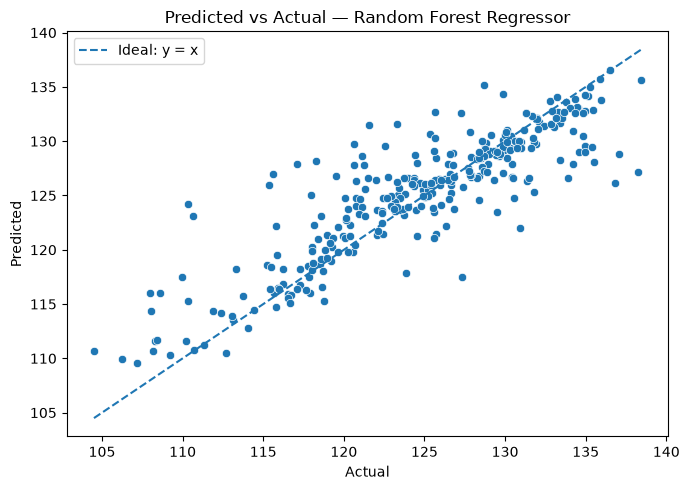

In [88]:
best_model_name = summary_table.iloc[0]["Model"]
best_predictions = predictions_store[best_model_name]

print("Best model by test-set R2:", best_model_name)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=best_predictions)
lims = [
    min(y_test.min(), best_predictions.min()),
    max(y_test.max(), best_predictions.max())
]
plt.plot(lims, lims, linestyle="--", label="Ideal: y = x")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.tight_layout()
plt.show()


### Predicted-vs-actual observation

Points close to the diagonal `y = x` line represent predictions close to the actual target values. The amount of scatter around the line provides a visual indication of prediction error for the model selected from the measured test-set R² comparison.


## 6A. Best-model residual plot

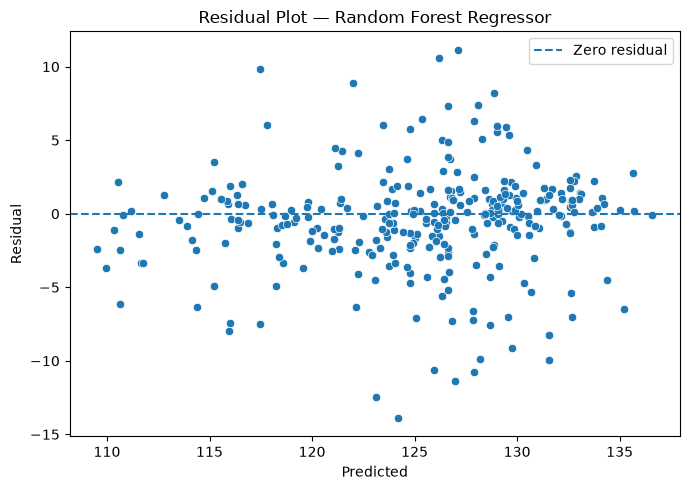

In [89]:
residuals = y_test - best_predictions

plt.figure(figsize=(7, 5))
sns.scatterplot(x=best_predictions, y=residuals)
plt.axhline(0, linestyle="--", label="Zero residual")
plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()


### Residual observation

Residuals should ideally be distributed around zero without a strong systematic pattern. Large isolated residuals indicate observations where the model has greater prediction error.


## 6B. Tree-based feature importance plot

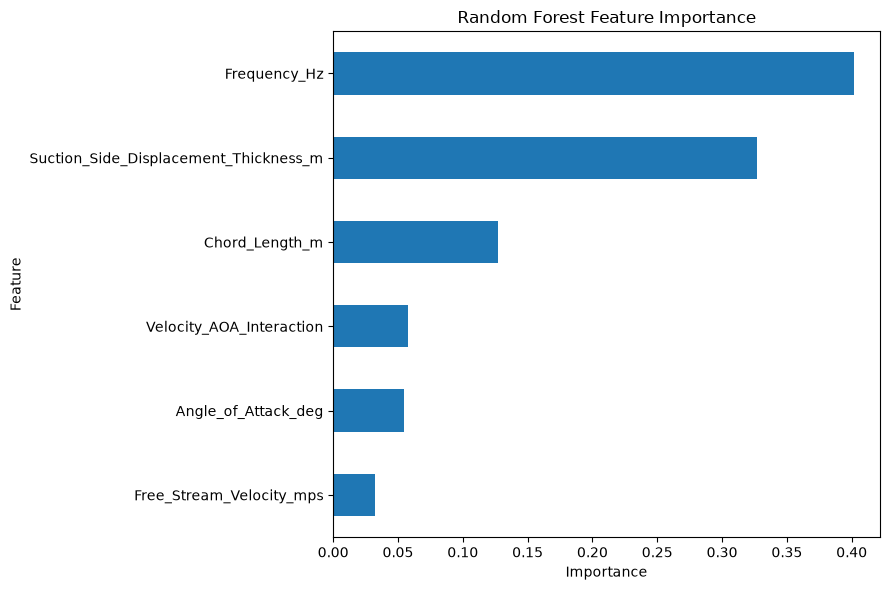

,importance
Frequency_Hz,0.401736
Suction_Side_Displacement_Thickness_m,0.327140
Chord_Length_m,0.126783
Velocity_AOA_Interaction,0.057517
Angle_of_Attack_deg,0.054491
Free_Stream_Velocity_mps,0.032333


In [90]:

# Random Forest 
rf_model = models_store["Random Forest Regressor"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(
    importance.sort_values(ascending=False)
    .to_frame("importance")
)


### Feature-importance observation

The Random Forest feature-importance plot shows the relative contribution of each engineered/input feature according to the fitted tree ensemble. The feature with the largest importance is the strongest contributor under this model's impurity-based importance measure; this should be interpreted as model-specific importance.
